In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/projects/bhdw/asachan/bioinfo_analysis/TA_muscle_ageing/scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import scanpy as sc

# Append the src directory to the path
current_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(current_dir, '..', 'src'))
if src_dir not in sys.path:
    sys.path.append(src_dir)

working_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects"

In [3]:
human_adata = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata = sc.read_h5ad(human_adata)

In [4]:
adata.obs['age'].value_counts()

age
80    2000
34    1989
Name: count, dtype: int64

In [5]:
adata.obs['Annotation'].value_counts()

Annotation
Type II        3391
ENOX1+ (II)     350
ID1+ (II)       241
DCLK1+ (II)       4
SAA2+ (II)        2
TNNT2+ (II)       1
Name: count, dtype: int64

In [6]:
adata

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

#### Sparsity based gene filtering

In [7]:
import numpy as np
from scipy.sparse import issparse

def calculate_zero_proportion(adata, axis='genes'):
    """
    Calculate the proportion of zeros for either genes (features) or cells in an AnnData object.
    
    Parameters:
    -----------
    adata : AnnData
        The AnnData object containing gene expression data
    axis : str, default 'genes'
        Which axis to calculate zeros for:
        - 'genes' or 'features' or 'columns': calculate zeros per gene (column-wise)
        - 'cells' or 'rows': calculate zeros per cell (row-wise)
        
    Returns:
    --------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each gene or cell
    """
    if axis.lower() in ['genes', 'features', 'columns']:
        # Calculate zeros per gene (column-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_cells = adata.n_obs
            non_zero_per_gene = np.array((adata.X != 0).sum(axis=0)).flatten()
            zero_per_gene = n_cells - non_zero_per_gene
            proportion_zeros = zero_per_gene / n_cells
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=0) / adata.n_obs
            
    elif axis.lower() in ['cells', 'rows']:
        # Calculate zeros per cell (row-wise)
        if issparse(adata.X):
            # For sparse matrix: count non-zeros, then calculate zeros
            n_genes = adata.n_vars
            non_zero_per_cell = np.array((adata.X != 0).sum(axis=1)).flatten()
            zero_per_cell = n_genes - non_zero_per_cell
            proportion_zeros = zero_per_cell / n_genes
        else:
            # For dense matrix
            proportion_zeros = (adata.X == 0).sum(axis=1) / adata.n_vars
    else:
        raise ValueError("axis must be 'genes', 'features', 'columns', 'cells', or 'rows'")
    
    return proportion_zeros

def plot_sparsity_analysis(proportion_zeros, str='features', figsize=(14, 5), bins=50, 
                                color='steelblue', alpha=0.7, show_stats=True):
    """
    Plot cell/feature sparsity analysis with histogram and cumulative distribution.
    
    Parameters:
    -----------
    proportion_zeros : numpy.ndarray
        Array containing the proportion of zeros for each feature/cell
    figsize : tuple, default (14, 5)
        Figure size for the plots
    bins : int, default 50
        Number of bins for the histogram
    color : str, default 'steelblue'
        Color for the histogram bars
    alpha : float, default 0.7
        Transparency for the histogram bars
    show_stats : bool, default True
        Whether to print summary statistics
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    axes : numpy.ndarray
        Array of axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Histogram of cell/feature sparsity
    axes[0].hist(proportion_zeros, bins=bins, edgecolor='black', alpha=alpha, color=color)
    axes[0].set_xlabel('Proportion of zeros')
    axes[0].set_ylabel('Number of ' + str)
    axes[0].set_title('Sparsity')
    axes[0].axvline(proportion_zeros.mean(), color='red', linestyle='--', 
                    label=f'Mean = {proportion_zeros.mean():.2f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Cumulative distribution
    sorted_props = np.sort(proportion_zeros)
    cumulative = np.arange(1, len(sorted_props) + 1) / len(sorted_props)
    axes[1].plot(sorted_props, cumulative, linewidth=2)
    axes[1].set_xlabel('Proportion of zeros')
    axes[1].set_ylabel('Cumulative fraction of ' + str)
    axes[1].set_title('Cumulative Distribution of Sparsity')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary statistics
    if show_stats:
        print(f"Total {str}: {len(proportion_zeros)}")
        print(f"Mean proportion of zeros: {proportion_zeros.mean():.3f}")
        print(f"Median proportion of zeros: {np.median(proportion_zeros):.3f}")
        print(f"\n{str} by sparsity:")
        print(f"  >95% zeros: {(proportion_zeros > 0.95).sum()} {str} ({(proportion_zeros > 0.95).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >94% zeros: {(proportion_zeros > 0.94).sum()} {str} ({(proportion_zeros > 0.94).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  >90% zeros: {(proportion_zeros > 0.90).sum()} {str} ({(proportion_zeros > 0.90).sum()/len(proportion_zeros)*100:.1f}%)")
        print(f"  All zeros:  {(proportion_zeros == 1.0).sum()} {str}")
    
    return fig, axes


In [8]:
proportion_zeros_feature = calculate_zero_proportion(adata, axis='features')

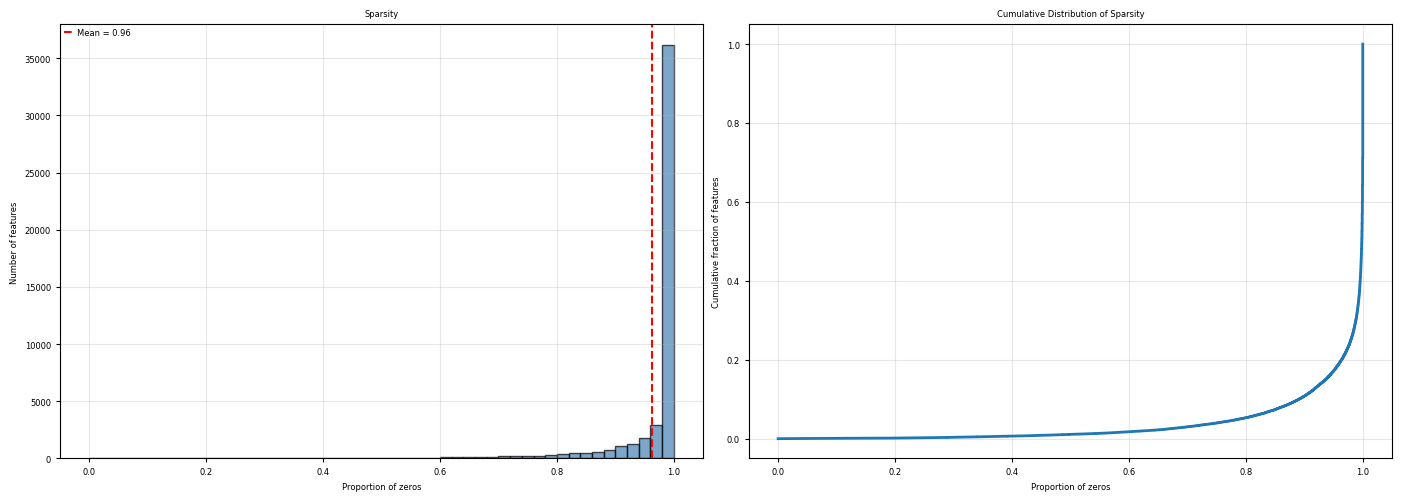

Total features: 48355
Mean proportion of zeros: 0.963
Median proportion of zeros: 0.998

features by sparsity:
  >95% zeros: 40066 features (82.9%)
  >94% zeros: 40858 features (84.5%)
  >90% zeros: 43140 features (89.2%)
  All zeros:  13973 features


In [9]:
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')

In [10]:
# Remove genes with all zeros
genes_to_keep = proportion_zeros_feature < 0.9

print(f"Before filtering: {adata.n_vars} genes")
adata_filtered = adata[:, genes_to_keep]
print(f"After filtering: {adata_filtered.n_vars} genes")
print(f"Removed: {(~genes_to_keep).sum()} genes")

Before filtering: 48355 genes
After filtering: 5215 genes
Removed: 43140 genes


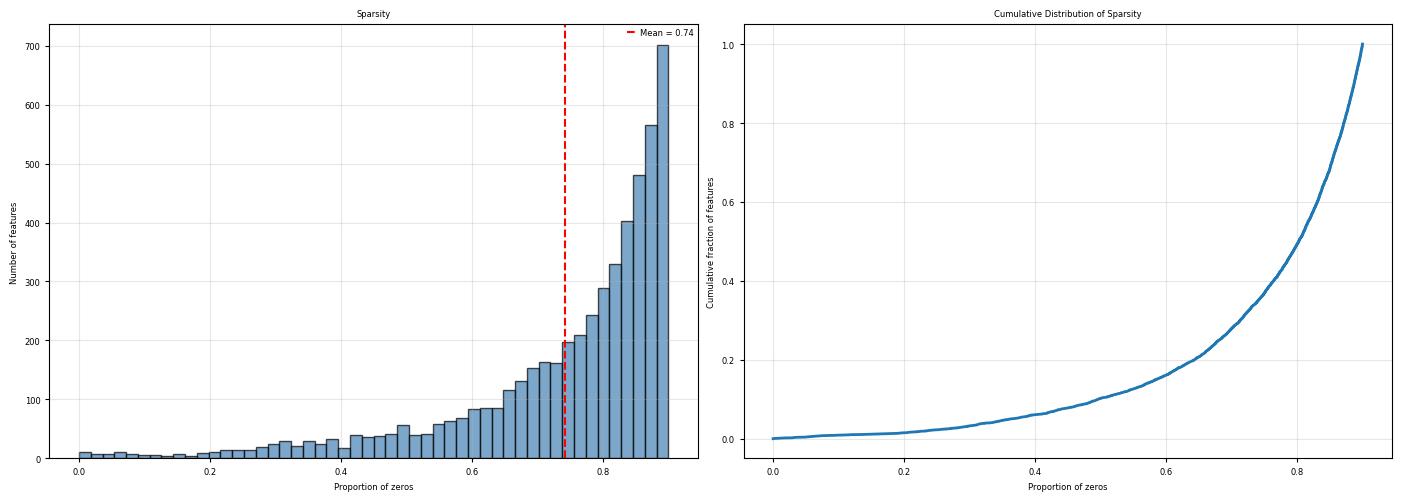

Total features: 5215
Mean proportion of zeros: 0.742
Median proportion of zeros: 0.803

features by sparsity:
  >95% zeros: 0 features (0.0%)
  >94% zeros: 0 features (0.0%)
  >90% zeros: 0 features (0.0%)
  All zeros:  0 features


In [11]:
proportion_zeros_feature = calculate_zero_proportion(adata_filtered, axis='features')
# Plot the analysis
fig, axes = plot_sparsity_analysis(proportion_zeros_feature, str='features')

### Variance based filtering

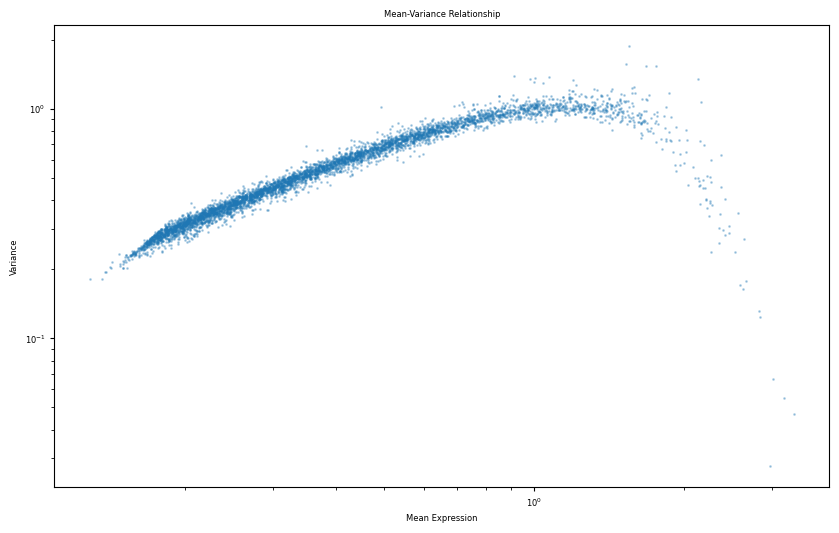

In [12]:
# Calculate mean and variance for each gene
gene_mean = np.mean(adata_filtered.X.toarray() if hasattr(adata_filtered.X, 'toarray') else adata_filtered.X, axis=0)
gene_variance = np.var(adata_filtered.X.toarray() if hasattr(adata_filtered.X, 'toarray') else adata_filtered.X, axis=0)

# Add variance to adata.var for easy access
adata_filtered.var['variance'] = gene_variance

plt.figure(figsize=(10, 6))
plt.scatter(gene_mean, gene_variance, alpha=0.3, s=1)
plt.xlabel('Mean Expression')
plt.ylabel('Variance')
plt.title('Mean-Variance Relationship')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [13]:
adata_df = adata_filtered.to_df()
adata_df

,AL669831.3,MTATP6P1,LINC01128,INTS11,DVL1,CCNL2,MRPL20,ATAD3B,SSU72,MIB2,...,TXLNGY,Z83843.1,SNHG20,WBP1,AC004890.2,AL137127.1,AP000769.5,CSNK2B,AC005495.1,AC105339.2
CELL303_N2_1_1_6_1,0.000000,0.000000,1.796355,1.470937,0.000000,1.791874,0.000000,1.480646,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.486078,0.000000,0.000000,0.000000
CELL2900_N1_1_1_6_1,0.000000,0.000000,0.000000,0.000000,0.000000,2.494645,0.000000,2.349542,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,2.061158,0.000000,0.000000,0.000000
CELL2202_N1_1_1_6_1,0.000000,1.597174,0.000000,0.000000,0.000000,1.779781,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL3194_N1_1_1_6_1,0.000000,0.000000,2.032342,0.000000,0.000000,0.000000,0.000000,2.034953,2.017415,0.0,...,0.0,2.028301,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL523_N2_1_1_6_1,0.000000,0.000000,0.000000,1.486220,0.000000,1.478953,0.000000,1.496703,1.452418,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.497899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL1197_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,2.260486,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,2.435014,0.000000
CELL1397_N1_1_11_1,1.652335,0.000000,0.000000,0.000000,0.000000,2.301100,1.951917,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,2.460948,0.000000,2.308254,0.000000,0.000000
CELL350_N1_1_11_1,0.000000,0.000000,1.636584,0.000000,0.000000,0.000000,2.361123,0.000000,0.000000,0.0,...,0.0,0.000000,1.651935,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CELL1777_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
# Sort Y by Class
Y_sorted = adata_filtered.obs.sort_values('age', ascending=True)

# Reorder adata_df to match the same order
adata_df_sorted = adata_df.loc[Y_sorted.index]

# Verify the order is synchronized
print("Y sorted:")
display(Y_sorted)
print(f"\nold samples (Class=1): {(Y_sorted['age'] == 80).sum()}")
print(f"young samples (Class=0): {(Y_sorted['age'] == 34).sum()}")

print("\nX matrix sorted:")
display(adata_df_sorted)

# Verify indices match
print(f"\nIndices match: {(Y_sorted.index == adata_df_sorted.index).all()}")

Y sorted:


,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,Pseudotime,Pseudotime_typeI,Pseudotime_typeII,bead_count,age_categorical,GOBP_DNA_DAMAGE_RESPONSE,GOBP_DNA_REPAIR,HALLMARK_DNA_REPAIR,REACTOME_DNA_REPAIR
CELL1846_N1_1_11_1,YM2_3,1969.6556,1060,YM2,0.004421,34,snRNA,Female,China,young_pop,Type II,71.0,NaN,71.0,NaN,34,0.064027,0.065539,0.024404,0.040961
CELL1883_N1_1_11_1,YM2_3,2062.5045,1126,YM2,0.035666,34,snRNA,Female,China,young_pop,Type II,82.0,NaN,82.0,NaN,34,0.071213,0.062335,0.042504,0.041052
CELL1792_N1_1_11_1,YM2_3,2166.3777,1150,YM2,0.123533,34,snRNA,Female,China,young_pop,Type II,69.0,NaN,69.0,NaN,34,0.060620,0.053820,0.038525,0.043010
CELL1155_N1_1_11_1,YM2_3,2238.1964,1283,YM2,0.012258,34,snRNA,Female,China,young_pop,Type II,78.0,NaN,78.0,NaN,34,0.070834,0.061841,0.044855,0.052221
CELL185_N1_1_11_1,YM2_3,2684.2806,1976,YM2,0.000000,34,snRNA,Female,China,young_pop,Type II,NaN,NaN,NaN,NaN,34,0.084429,0.079574,0.039427,0.069667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL1230_N1_1_1_6_1,OM6_1,3138.1277,2472,OM6,1.844039,80,snRNA,Female,China,old_pop,ID1+ (II),99.0,NaN,99.0,NaN,80,0.080121,0.058384,0.049136,0.056687
CELL2613_N1_1_1_6_1,OM6_1,2652.8350,1523,OM6,0.222464,80,snRNA,Female,China,old_pop,Type II,59.0,NaN,59.0,NaN,80,0.077159,0.062075,0.046398,0.071748
CELL2202_N1_1_1_6_1,OM6_1,2602.6083,1572,OM6,0.019580,80,snRNA,Female,China,old_pop,ID1+ (II),94.0,NaN,94.0,NaN,80,0.077198,0.067654,0.062925,0.067493
CELL2900_N1_1_1_6_1,OM6_1,2202.0882,1248,OM6,0.463730,80,snRNA,Female,China,old_pop,Type II,33.0,NaN,33.0,NaN,80,0.082784,0.067559,0.059456,0.052412



old samples (Class=1): 2000
young samples (Class=0): 1989

X matrix sorted:


,AL669831.3,MTATP6P1,LINC01128,INTS11,DVL1,CCNL2,MRPL20,ATAD3B,SSU72,MIB2,...,TXLNGY,Z83843.1,SNHG20,WBP1,AC004890.2,AL137127.1,AP000769.5,CSNK2B,AC005495.1,AC105339.2
CELL1846_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,2.440431,0.000000
CELL1883_N1_1_11_1,0.000000,0.000000,2.401586,0.000000,0.000000,0.000000,0.0,0.000000,2.054235,0.0,...,0.0,2.113349,2.098526,0.0,2.098703,0.000000,0.000000,0.0,2.558855,0.000000
CELL1792_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,2.010017,2.489826,0.0,2.040375,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,2.029866,0.000000,0.0,2.347664,0.000000
CELL1155_N1_1_11_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
CELL185_N1_1_11_1,0.000000,0.000000,2.218602,1.460040,0.000000,0.000000,0.0,2.020888,1.389764,0.0,...,0.0,0.000000,2.136287,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL1230_N1_1_1_6_1,0.000000,1.939554,1.374699,0.000000,1.706655,0.000000,0.0,0.000000,1.329771,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.389190,0.0,0.000000,0.000000
CELL2613_N1_1_1_6_1,1.584636,0.000000,0.000000,0.000000,0.000000,1.843332,0.0,0.000000,1.829960,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.853085
CELL2202_N1_1_1_6_1,0.000000,1.597174,0.000000,0.000000,0.000000,1.779781,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
CELL2900_N1_1_1_6_1,0.000000,0.000000,0.000000,0.000000,0.000000,2.494645,0.0,2.349542,0.000000,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,2.061158,0.0,0.000000,0.000000



Indices match: True


In [15]:
# Update the original variables
Y = Y_sorted['age']
adata_df = adata_df_sorted

In [16]:
display(Y)

CELL1846_N1_1_11_1     34
CELL1883_N1_1_11_1     34
CELL1792_N1_1_11_1     34
CELL1155_N1_1_11_1     34
CELL185_N1_1_11_1      34
                       ..
CELL1230_N1_1_1_6_1    80
CELL2613_N1_1_1_6_1    80
CELL2202_N1_1_1_6_1    80
CELL2900_N1_1_1_6_1    80
CELL303_N2_1_1_6_1     80
Name: age, Length: 3989, dtype: int32

In [17]:
#save to csv
out_dir = "/projects/bhdw/asachan/papers/pdk4_ercc1/plots"
adata_df.to_csv(os.path.join(out_dir, 'female_type2_human_X.csv'))

In [18]:
# save to csv
Y.to_csv(os.path.join(out_dir, 'female_type2_human_Y.csv'))

# Scoring the cells using Zs

In [19]:
# ============================================================
# Transfer learning: score HUMAN cells with a MOUSE SLIDE model
# ------------------------------------------------------------
# Reuse the A-loadings (+ C, Gamma) learnt by SLIDE / Essential Regression on
# MOUSE fast-2b/2x metacells (ERCC1-KO: WT=0 vs KO=1) to score human single
# cells via EssReg predZ -- the same cross-prediction the R script does, plus a
# mouse->human ortholog bridge. All the msachinery lives in
# `pgl.crossprediction`; this notebook just wires it together. No decoupler /
# AUCell -- scores come straight from the model A-loadings.
# ============================================================
import pygenelab as pgl
xp = pgl.crossprediction

# --- paths (mouse model = female_0.1_spec / 0.01_1_out) ------
MODEL_DIR = "/work/hdd/bhdw/asachan/ercc1_mice/female_0.1_spec/0.01_1_out"
MOUSE_X   = "/projects/bhdw/asachan/papers/pdk4_ercc1/plots/female_fast2b_2x_harmonyv2_X.csv"
MOUSE_Y   = "/projects/bhdw/asachan/papers/pdk4_ercc1/plots/female_fast2b_2x_harmonyv2_Y.csv"
ORTHOLOGS = "/work/hdd/bgdb/asachan/datasets_proj/gene_sets/human_mouse_1to1_orthologs.csv"
OUT_DIR   = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"

# load the trained mouse model (rpy2 + base-R readRDS; sets R_HOME internally)
model   = xp.load_slide_model(MODEL_DIR)
A_genes = model["genes"]
print(f"A: {model['A'].shape[0]} mouse genes x {model['A'].shape[1]} latent factors")
print(f"marginal LFs: {['Z%d' % v for v in model['marginal']]}")

# significant LFs = unique( marginal_vals U interaction$p2 ), exactly as in R
sig_lfs = xp.significant_lfs(model)
print(f"sig_lfs ({len(sig_lfs)}): {sig_lfs}")
assert "Z12" in sig_lfs, "Z12 (the LF of interest) is not among the significant factors!"

2026-09-06 23:02:52 | [INFO] cffi mode is CFFI_MODE.ANY


2026-09-06 23:02:52 | [INFO] R home found: /projects/bhdw/asachan/.conda/envs/decoupler_psc/lib/R


2026-09-06 23:02:52 | [INFO] R library path: /opt/cray/pe/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/math_libs/13.2/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/extras/CUPTI/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/nvvm/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/lib64:/opt/cray/libfabric/2.3.1/lib64


2026-09-06 23:02:52 | [INFO] LD_LIBRARY_PATH: /opt/cray/pe/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/math_libs/13.2/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/extras/CUPTI/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/nvvm/lib64:/opt/nvidia/hpc_sdk/Linux_x86_64/26.5/cuda/13.2/lib64:/opt/cray/libfabric/2.3.1/lib64


2026-09-06 23:02:52 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save


2026-09-06 23:02:52 | [INFO] R is already initialized. No need to initialize.


A: 1323 mouse genes x 55 latent factors
marginal LFs: ['Z5', 'Z15', 'Z29', 'Z38', 'Z42', 'Z45', 'Z55']
sig_lfs (15): ['Z5', 'Z15', 'Z29', 'Z38', 'Z42', 'Z45', 'Z55', 'Z46', 'Z33', 'Z27', 'Z54', 'Z36', 'Z8', 'Z12', 'Z1']


In [20]:
# ------------------------------------------------------------
# Mouse -> human ortholog bridge (1:1 table). The A-loadings live in MOUSE gene
# space; mouse genes with no 1:1 ortholog (or whose ortholog is absent from the
# human object) are zero-filled, like the R script's non-transferable genes.
# ------------------------------------------------------------
A_to_human, orth_stats = xp.build_human_ortholog_map(ORTHOLOGS, A_genes, adata.var_names)
print(f"A mouse genes with a 1:1 human ortholog        : {orth_stats['n_mapped']}/{orth_stats['n_total']}")
print(f"...and that ortholog present in the human data : {orth_stats['n_present']}/{orth_stats['n_total']} "
      f"({100 * orth_stats['frac_present']:.1f}%  -> the remainder are zero-filled)")

# Z12 drivers specifically (the LF of interest)
z12_genes   = pd.read_csv(os.path.join(MODEL_DIR, "feature_list_Z12.txt"), sep="\t")
z12_present = [g for g in z12_genes["names"] if g in A_to_human]
print(f"\nZ12 drivers: {len(z12_genes)} mouse genes, {len(z12_present)} transferable to human")
print("  transferred:", [f"{g}->{A_to_human[g]}" for g in z12_present])
print("  dropped    :", [g for g in z12_genes["names"] if g not in A_to_human])

A mouse genes with a 1:1 human ortholog        : 1022/1323
...and that ortholog present in the human data : 1015/1323 (76.7%  -> the remainder are zero-filled)

Z12 drivers: 19 mouse genes, 14 transferable to human
  transferred: ['Pdk4->PDK4', 'Ucp3->UCP3', 'Nrp1->NRP1', 'Commd10->COMMD10', 'Xirp2->XIRP2', 'Kcnq1->KCNQ1', 'Mybph->MYBPH', 'Tnfrsf19->TNFRSF19', 'Cyfip2->CYFIP2', 'Dmd->DMD', 'Npc1->NPC1', 'Tacc2->TACC2', 'Asb4->ASB4', 'Vldlr->VLDLR']
  dropped    : ['Pak7', 'Asap2', 'Nctc1', 'Fndc9', 'Aldh1a1']


In [21]:
# ------------------------------------------------------------
# predZ + alignment helpers all live in pgl.crossprediction now:
#   xp.standardize_cols   column z-score == SLIDE scale(x,T,T)
#   xp.predZ              Z = X Gamma^-1 A pinv(A^T Gamma^-1 A + C^-1)
#   xp.align_mouse_to_A / xp.align_human_to_A   gene-axis alignment + zero-fill
#   xp.project_mouse / xp.project_human         standardize -> predZ -> labelled Z
# Nothing to define here; kept as a marker cell.
print("predZ + projection helpers provided by pgl.crossprediction")

predZ + projection helpers provided by pgl.crossprediction


In [22]:
# ---- MOUSE (orig) -------------------------------------------------
mouse_x_df = pd.read_csv(MOUSE_X, index_col=0)
mouse_y_df = pd.read_csv(MOUSE_Y, index_col=0)
orig_y = mouse_y_df.iloc[:, 0].loc[mouse_x_df.index].astype(int).values     # 0=WT, 1=KO

# ---- HUMAN (new) --------------------------------------------------
age   = adata.obs["age"].astype(int).values
new_y = (age == age.max()).astype(int)        # old(80)=1, young(34)=0  (KO ~ accelerated aging)
print(f"mouse metacells: {mouse_x_df.shape[0]}   (WT/KO = {(orig_y==0).sum()}/{(orig_y==1).sum()})")
print(f"human cells    : {adata.n_obs}   (young/old = {(new_y==0).sum()}/{(new_y==1).sum()})")

mouse metacells: 451   (WT/KO = 232/219)
human cells    : 3989   (young/old = 1989/2000)


In [23]:
# ---- project both datasets onto the mouse latent factors ----------
orig_z = xp.project_mouse(mouse_x_df, model)               # mouse metacells x Z1..ZK
new_z  = xp.project_human(adata, model, A_to_human)        # human cells   x Z1..ZK

# sanity check: mouse predZ should reproduce the stored SLIDE z_matrix exactly
_zst = pd.read_csv(os.path.join(MODEL_DIR, "z_matrix.csv"), index_col=0)
_r = np.corrcoef(orig_z["Z12"].values, _zst.loc[orig_z.index, "Z12"].values)[0, 1]
print(f"mouse Z12 reproducibility vs stored z_matrix.csv: r = {_r:.4f}  (expect ~1.0)")

mouse Z12 reproducibility vs stored z_matrix.csv: r = 1.0000  (expect ~1.0)


In [24]:
# ------------------------------------------------------------
# Fit a linear model on the MOUSE latent factors (WT vs KO) and apply it,
# unchanged, to the human latent factors -- the R glm(gaussian) cross-prediction.
# ------------------------------------------------------------
from sklearn.metrics import roc_auc_score

fit = xp.fit_transfer_classifier(orig_z, orig_y, new_z, sig_lfs)
orig_pred, new_pred = fit["orig_pred"], fit["new_pred"]
orig_auc = fit["orig_auc"]
new_auc  = roc_auc_score(new_y, new_pred)
print(f"MOUSE  (WT vs KO)    self-AUC      : {orig_auc:.4f}")
print(f"HUMAN  (young vs old) transfer-AUC : {new_auc:.4f}")

MOUSE  (WT vs KO)    self-AUC      : 0.9896
HUMAN  (young vs old) transfer-AUC : 0.2611


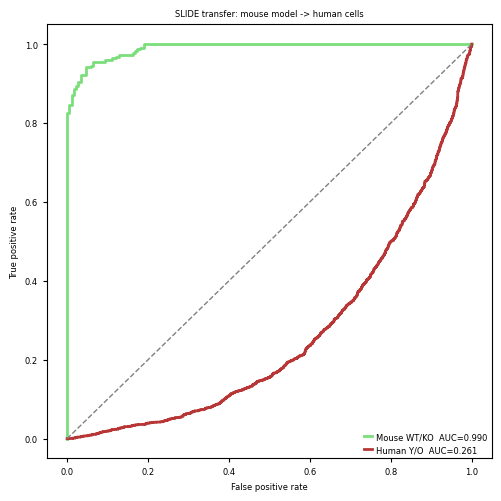

In [25]:
# ---- ROC: mouse self-prediction vs human transfer -----------------
roc_fig, _ = xp.plot_transfer_roc(
    orig_y, orig_pred, new_y, new_pred,
    orig_label="Mouse WT/KO", new_label="Human Y/O",
    title="SLIDE transfer: mouse model -> human cells")
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score
raw_auc = roc_auc_score(new_y, new_z["Z12"].reindex(adata.obs_names).values)
print(f"raw (unoriented) Z12 AUC = {raw_auc:.4f}")
print("orient_by flipped Z12:", raw_auc < 0.5)

raw (unoriented) Z12 AUC = 0.3708
orient_by flipped Z12: True


##### Per-cell Z12 transferred score
Project each human cell onto **Z12** using the mouse A-loadings (no retraining, no decoupler) and compare young vs old.

ortholog coverage: 1015/1323 A-genes (76.7%) transfer to human


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


attached: ['Z12_transfer_score']
Human Z12 score separates young vs old: AUC = 0.6292


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-09-06 23:02:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


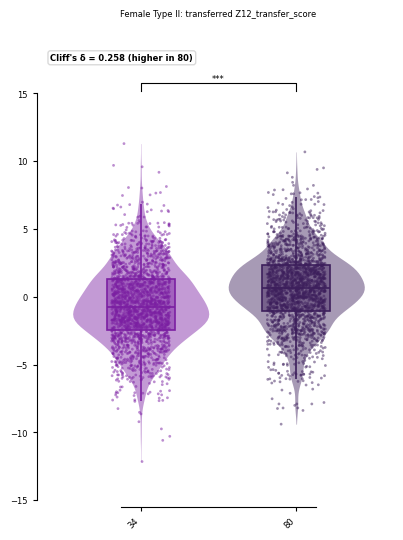

<Figure size 640x480 with 0 Axes>

In [27]:
# ------------------------------------------------------------
# Per-cell Z12 transferred score on the human cells, straight from the mouse
# A-loadings. `transfer_latent_scores` projects the cells and writes
# adata.obs["Z12_transfer_score"], sign-oriented so higher = older. Then the same
# Cliff's-delta + violin/scatter view used in
# 6_human_skm_multimodal/activity_score_trends.ipynb.
# ------------------------------------------------------------
xp.transfer_latent_scores(
    adata, MODEL_DIR, ORTHOLOGS,
    lfs=["Z12"], orient_by=new_y, verbose=True)

ADATA_NAME = "rna_female_type2"
SCORE_COL  = "Z12_transfer_score"
GROUP_COL  = "age_yrs"

# age as a categorical x-axis (youngest -> oldest)
adata.obs[GROUP_COL] = adata.obs["age"].astype(int).astype(str)
GROUPS = sorted(adata.obs[GROUP_COL].unique(), key=int)        # ['34', '80']
PALETTE = {GROUPS[0]: "#7B1FA2", GROUPS[1]: "#3D1F5C"}

z12_auc = roc_auc_score(new_y, adata.obs[SCORE_COL].values)
print(f"Human Z12 score separates young vs old: AUC = {z12_auc:.4f}")

# Cliff's delta between youngest and oldest age
cliffs_df, _ = pgl.calculate_score_cliffs_delta(
    adata=adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    group1=GROUPS[0],
    group2=GROUPS[-1],
)
cliffs_row = cliffs_df.iloc[0]
DELTA_LABEL = (
    f"Cliff's δ = {float(cliffs_row['abs_cliffs_delta']):.3f} "
    f"(higher in {cliffs_row['higher_group']})"
)

plot_df, violin_fig = pgl.plot_score_by_group(
    adata=adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    palette=PALETTE,
    group_order=list(GROUPS),
    title=f"Female Type II: transferred {SCORE_COL}",
    show_scatter=True,
    scatter_alpha=0.5,
    scatter_size=2,
    show_pvalue=False,
    delta_label=DELTA_LABEL,
    group_spacing=0.8,
    ylim=None,
)
violin_fig.savefig(
    os.path.join(OUT_DIR, f"female_type2_human_{SCORE_COL}_by_age_violin.svg"),
    bbox_inches="tight",
)
violin_fig

{'Mouse WT/KO (Z12)': np.float64(0.6584986616280901), 'Human Y/O (Z12, KO-aligned)': np.float64(0.6291827551533434)}


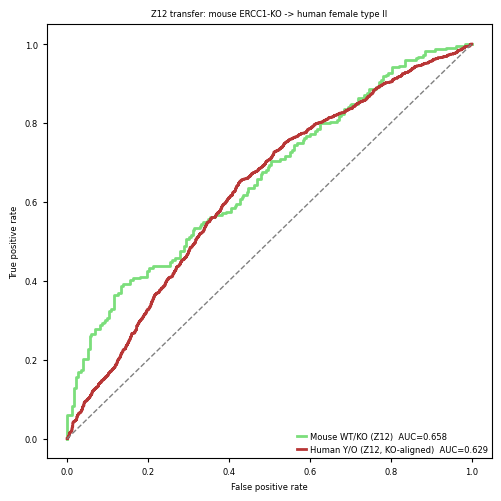

In [28]:
# ---- ROC on the Z12 latent factor alone (replaces the 15-LF classifier ROC) ----
# Mouse: raw Z12 score, higher = ERCC1-KO (AUC 0.658).
# Human: Z12 score sign-aligned so the KO-high direction scores old cells high
# (AUC 0.629). Justification: the A-loadings are kept fixed, and the top Z12
# driver PDK4 is up in KO mice and up in old human type II fibres (see driver
# heatmap below), so the aligned sign is the biologically concordant one.
# Raw (unaligned) human Z12 AUC is 1 - 0.629 = 0.371.
z12_roc_fig, z12_aucs = xp.plot_transfer_roc(
    orig_y, orig_z["Z12"].values,
    new_y,  adata.obs["Z12_transfer_score"].values,
    orig_label="Mouse WT/KO (Z12)",
    new_label="Human Y/O (Z12, KO-aligned)",
    title="Z12 transfer: mouse ERCC1-KO -> human female type II",
)
print(z12_aucs)
z12_roc_fig.savefig(os.path.join(OUT_DIR, "female_type2_human_Z12_transfer_roc.svg"),
                    bbox_inches="tight")
plt.show()

saved -> /work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/female_type2_human_Z12_transfer_drivers_heatmap.png


,young (34),old (80),A_loading,direction
PDK4,-0.33,0.33,1.00,1
UCP3,-0.12,0.12,1.00,1
NRP1,0.05,-0.05,0.11,-1
COMMD10,0.02,-0.02,0.08,-1
XIRP2,0.32,-0.32,0.08,-1
KCNQ1,-0.00,0.00,0.07,-1
MYBPH,-0.27,0.27,0.07,1
TNFRSF19,0.06,-0.06,0.07,1
CYFIP2,0.06,-0.06,0.04,1
DMD,0.43,-0.43,0.04,1


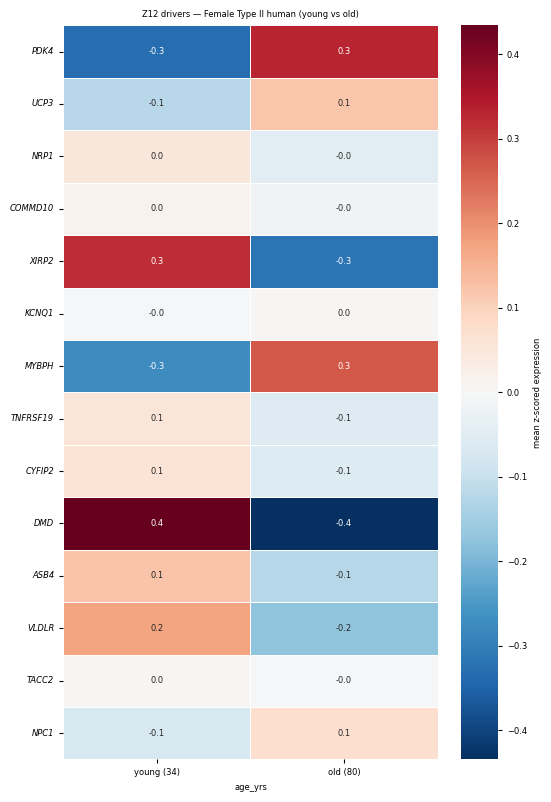

In [29]:
# ── driver-gene heatmap for the transferred Z12 score (human) ──
# A biologist-facing view of Z12's drivers (instead of a within-age correlation,
# which can flip sign even when a gene is clearly up in old):
#   heatmap = each driver's mean z-scored expression in young vs old human cells
#             (red = above-average for that age, e.g. PDK4 up in old)
# Genes are ordered by SLIDE A_loading (driver strength). Pass
# show_loading_bar=True to add the A_loading side bar.
adata.obs["age_yrs"] = adata.obs["age"].astype(int).astype(str)
GROUPS = sorted(adata.obs["age_yrs"].unique(), key=int)        # ['34', '80'] = young, old

drv_tab, drv_fig = xp.plot_transferred_driver_heatmap(
    adata, MODEL_DIR, "Z12", ORTHOLOGS,
    group_col="age_yrs", groups=GROUPS, group_labels=["young (34)", "old (80)"],
    top_n=20,
    title="Z12 drivers — Female Type II human (young vs old)",
)
drv_stem = "female_type2_human_Z12_transfer_drivers_heatmap"
drv_fig.savefig(os.path.join(OUT_DIR, f"{drv_stem}.svg"), bbox_inches="tight")
drv_fig.savefig(os.path.join(OUT_DIR, f"{drv_stem}.png"), dpi=300, bbox_inches="tight")
print(f"saved -> {os.path.join(OUT_DIR, drv_stem + '.png')}")
drv_tab.round(2)

In [30]:
# ---- save transferred latent factors + Z12 score ------------------
new_z.to_csv(os.path.join(OUT_DIR, "female_type2_human_transferred_Z.csv"))
adata.obs[["age", "Z12_transfer_score"]].to_csv(
    os.path.join(OUT_DIR, "female_type2_human_Z12_score.csv"))
print("saved:")
print("  ", os.path.join(OUT_DIR, "female_type2_human_transferred_Z.csv"))
print("  ", os.path.join(OUT_DIR, "female_type2_human_Z12_score.csv"))

saved:
   /work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/female_type2_human_transferred_Z.csv
   /work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/female_type2_human_Z12_score.csv
